In [ ]:
import pandas as pd

ratings = pd.read_csv('u.data', sep='\t', header=None,
                      names=['user_id', 'movie_id', 'rating', 'timestamp'])

movies = pd.read_csv('u.item', sep='|', encoding='latin-1',
                     header=None, usecols=[0, 1],
                     names=['movie_id', 'title'])

data = pd.merge(ratings, movies, on='movie_id')

print(data.head())

   user_id  movie_id  rating  timestamp                       title
0      196       242       3  881250949                Kolya (1996)
1      186       302       3  891717742    L.A. Confidential (1997)
2       22       377       1  878887116         Heavyweights (1994)
3      244        51       2  880606923  Legends of the Fall (1994)
4      166       346       1  886397596         Jackie Brown (1997)


In [2]:
print(data.info())
print(data.describe())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    100000 non-null  int64 
 1   movie_id   100000 non-null  int64 
 2   rating     100000 non-null  int64 
 3   timestamp  100000 non-null  int64 
 4   title      100000 non-null  object
dtypes: int64(4), object(1)
memory usage: 3.8+ MB
None
            user_id       movie_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.0

In [3]:
user_item_matrix = data.pivot_table(index='user_id',
                                    columns='title',
                                    values='rating')

In [4]:
user_item_filled = user_item_matrix.fillna(0)

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_filled)

import pandas as pd
user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

In [6]:
def get_similar_users(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    return similar_users.iloc[1:n+1]

print(get_similar_users(1))

user_id
916    0.566293
864    0.549277
457    0.541364
92     0.539415
268    0.538883
Name: 1, dtype: float64


In [7]:
import numpy as np

def predict_ratings(user_id, top_n=5):
    similar_users = get_similar_users(user_id, top_n)
    
    user_ratings = user_item_matrix.loc[user_id]
    unseen_movies = user_ratings[user_ratings.isna()].index
    
    predictions = {}
    
    for movie in unseen_movies:
        weighted_sum = 0
        similarity_sum = 0
        
        for sim_user, similarity in similar_users.items():
            rating = user_item_matrix.loc[sim_user, movie]
            
            if not np.isnan(rating):
                weighted_sum += similarity * rating
                similarity_sum += similarity
        
        if similarity_sum != 0:
            predictions[movie] = weighted_sum / similarity_sum
    
    return predictions

In [8]:
def recommend_movies(user_id, n=5):
    predictions = predict_ratings(user_id)
    
    recommended = sorted(predictions.items(),
                         key=lambda x: x[1],
                         reverse=True)
    
    return recommended[:n]

print(recommend_movies(1, 5))

[('Alien: Resurrection (1997)', np.float64(5.0)), ('Casablanca (1942)', np.float64(5.0)), ('Chinatown (1974)', np.float64(5.0)), ('City of Lost Children, The (1995)', np.float64(5.0)), ('Diva (1981)', np.float64(5.0))]


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

train, test = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train.pivot_table(index='user_id',
                                 columns='movie_id',
                                 values='rating').fillna(0)

similarity = cosine_similarity(train_matrix)

def evaluate():
    preds = []
    actuals = []
    
    for _, row in test.iterrows():
        user = row['user_id']
        movie = row['movie_id']
        actual = row['rating']
        
        if user in train_matrix.index and movie in train_matrix.columns:
            user_idx = train_matrix.index.get_loc(user)
            sim_scores = similarity[user_idx]
            movie_ratings = train_matrix[movie]
            
            if np.sum(sim_scores) != 0:
                pred = np.dot(sim_scores, movie_ratings) / np.sum(sim_scores)
                
                preds.append(pred)
                actuals.append(actual)
    
    return preds, actuals

preds, actuals = evaluate()

rmse = np.sqrt(mean_squared_error(actuals, preds))
mae = mean_absolute_error(actuals, preds)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.9951921793503575
MAE: 2.7955103130588648


In [10]:
import numpy as np

sparsity = 1 - (np.count_nonzero(user_item_matrix) / user_item_matrix.size)
print("Sparsity:", sparsity)

Sparsity: 0.0


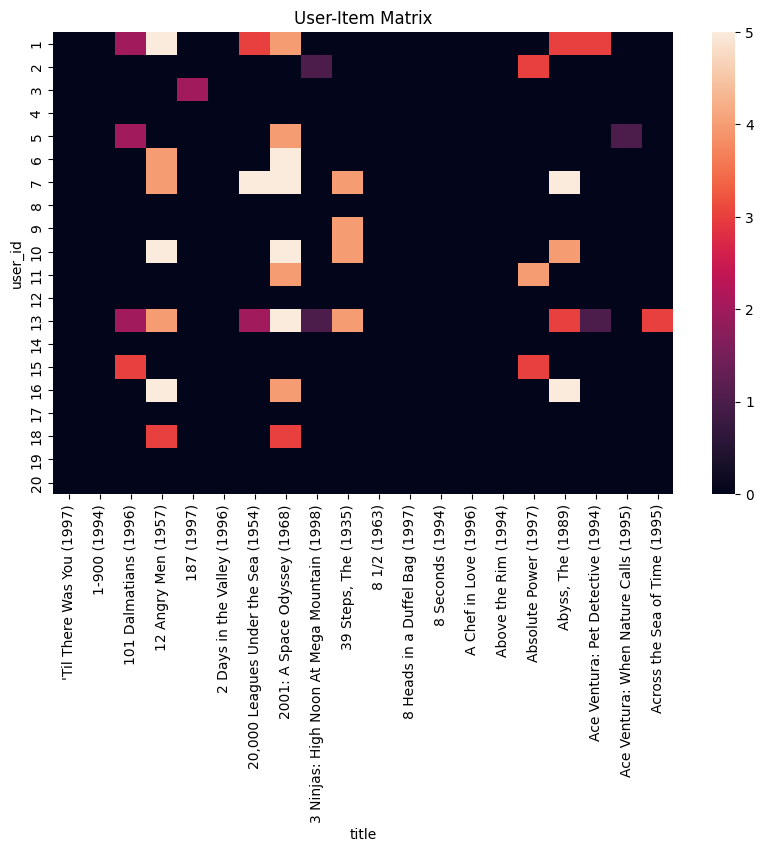

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("User-Item Matrix")
plt.show()

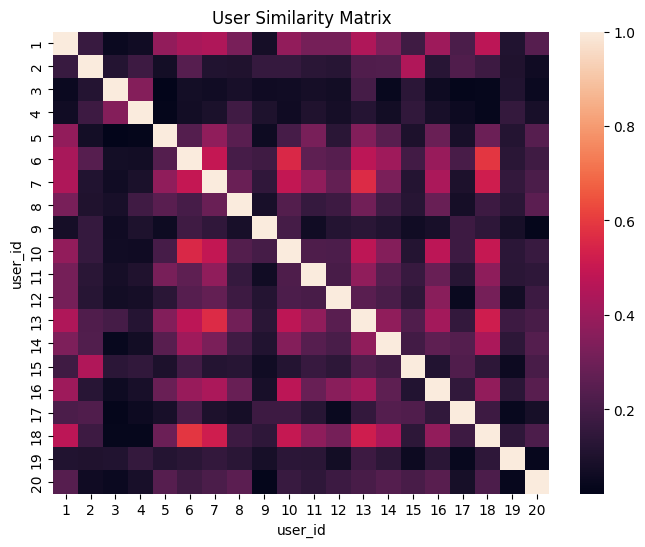

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.title("User Similarity Matrix")
plt.show()

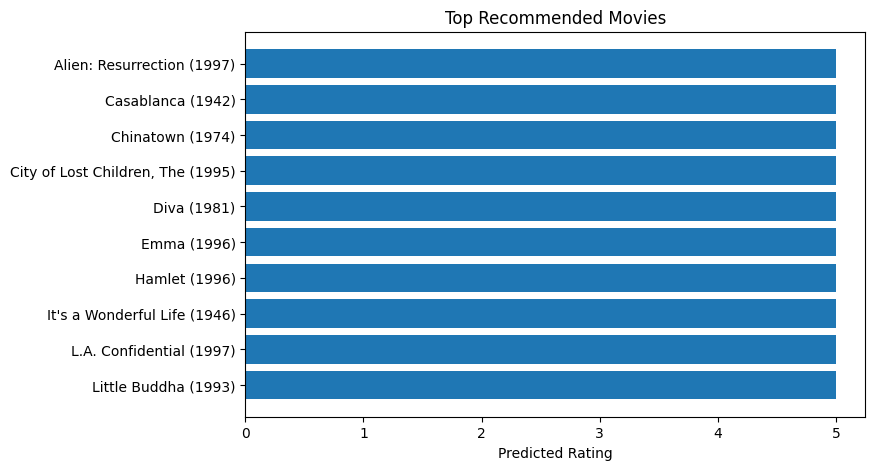

In [13]:
recommended = recommend_movies(1, 10)

movies, scores = zip(*recommended)

plt.figure(figsize=(8,5))
plt.barh(movies, scores)
plt.title("Top Recommended Movies")
plt.xlabel("Predicted Rating")
plt.gca().invert_yaxis()
plt.show()